# Práctica 1 
**Estadística, vectores, probabilidad, preprocesamiento y descenso de gradiente**

* **Estudiante:** Anahi Lourdes Oquendo Chucusea
* **Carrera:** Ingeniería Informática
* **Semestre:** 6º semestre
* **Gestión:** 2026-02
* **Docente:** M. Sc. Huáscar Fedor Gonzales Guzmán
* **Universidad:** Universidad Autónoma Tomás Frías

## Configuración del entorno
Importamos las librerías necesarias (`numpy`, `pandas`, `matplotlib`, `seaborn`, `itertools`) y configuramos las semillas y estilos gráficos para garantizar la reproducibilidad de los 10 ejercicios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Configuración del generador de números aleatorios para reproducibilidad
rng = np.random.default_rng(42)

# Estilo gráfico homogéneo "cuaderno científico"
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_theme(style="whitegrid")

INDIGO, PURPURA, CORAL = "#4F46E5", "#7E22CE", "#F43F5E"
print("Entorno y librerías cargadas correctamente.")

Entorno y librerías cargadas correctamente.


## EJERCICIO 01: ¿Cuánto sale par? Estima una probabilidad tirando el dado

Generamos tiradas de dados para estimar la probabilidad empírica de obtener un número par con $N = 100$, $N = 1\,000$ y $N = 100\,000$ lanzamientos, comparándolo con el valor teórico $P(\text{par}) = 0.5$.

In [2]:
# Tamaños de muestra a experimentar
tamanos = [100, 1000, 100000]
resultados_e1 = {}

for N in tamanos:
    # 1. Generar N lanzamientos
    tiradas = rng.integers(1, 7, size=N)
    # 2. Máscara booleana para conteo de pares
    conteo_pares = (tiradas % 2 == 0).sum()
    # 3. Frecuencia relativa (estimación empírica)
    prob_estimada = conteo_pares / N
    resultados_e1[N] = prob_estimada

# Presentación de resultados
df_e1 = pd.DataFrame({
    "N (Lanzamientos)": resultados_e1.keys(),
    "Probabilidad Estimada": resultados_e1.values(),
    "Valor Teórico": 0.5,
    "Diferencia Absoluta": [abs(v - 0.5) for v in resultados_e1.values()]
})
df_e1

,N (Lanzamientos),Probabilidad Estimada,Valor Teórico,Diferencia Absoluta
0,100,0.38000,0.5,0.12000
1,1000,0.48900,0.5,0.01100
2,100000,0.49979,0.5,0.00021


### RESPUESTAS:

* **Comparación:**
  * Con $N = 100$, la estimación difiere del valor teórico debido a la variabilidad de muestras pequeñas.
  * Con $N = 1\,000$, la estimación se aproxima significativamente a $0.5$.
  * Con $N = 100\,000$, la probabilidad empírica converge de forma sumamente precisa al valor teórico $0.5$.
* **¿Cuál se acercó más y por qué?** 
  La estimación con **$N = 100\,000$** se acercó más. Esto responde a la **Ley de los Grandes Números**, la cual establece que a medida que el tamaño de la muestra aumenta, la frecuencia relativa de un evento aleatorio converge a su probabilidad teórica real.
* **¿Qué le pasa a la estimación cuando tienes pocos datos?**
  Cuando se tienen pocos datos (e.g., $N=100$), la estimación sufre de alta varianza empírica y es muy sensible al ruido aleatorio, pudiendo alejarse del valor teórico esperado.

## EJERCICIO 02: Radiografía de una característica

Analizamos descriptivamente la columna `petal_length` del dataset Iris utilizando estadísticas de tendencia central, dispersión y rango con NumPy[cite: 3].

In [3]:
from sklearn.datasets import load_iris

# 1. Cargar Iris y extraer petal_length (columna índice 2)
iris_data = load_iris()
df_iris_base = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
petal_length = df_iris_base["petal length (cm)"].to_numpy()

# 2. Medidas estadísticas con NumPy
media = np.mean(petal_length)
mediana = np.median(petal_length)
std = np.std(petal_length)
minimo = np.min(petal_length)
maximo = np.max(petal_length)

print(f"Media: {media:.2f} cm")
print(f"Mediana: {mediana:.2f} cm")
print(f"Desviación Estándar: {std:.2f} cm")
print(f"Mínimo: {minimo:.2f} cm")
print(f"Máximo: {maximo:.2f} cm")

Media: 3.76 cm
Mediana: 4.35 cm
Desviación Estándar: 1.76 cm
Mínimo: 1.00 cm
Máximo: 6.90 cm


### RESPUESTAS:

* **Cinco frases de interpretación:**
  1. **Media ($3.76\text{ cm}$):** El largo promedio del pétalo considerando todas las flores analizadas es de $3.76\text{ cm}$[cite: 3].
  2. **Mediana ($4.35\text{ cm}$):** Exactamente el 50% de las flores observadas tienen un largo de pétalo menor o igual a $4.35\text{ cm}$[cite: 3].
  3. **Desviación Estándar ($1.76\text{ cm}$):** Es grande respecto a la media, lo que indica que los datos están dispersos y los pétalos varían considerablemente de tamaño entre flores[cite: 3].
  4. **Mínimo ($1.00\text{ cm}$):** La flor con el pétalo más pequeño en la muestra mide $1.00\text{ cm}$[cite: 3].
  5. **Máximo ($6.90\text{ cm}$):** La flor con el pétalo más grande alcanza los $6.90\text{ cm}$[cite: 3].

* **¿La media y la mediana están cerca o lejos entre sí? ¿Qué sugiere sobre la distribución?**
  La media ($3.76\text{ cm}$) y la mediana ($4.35\text{ cm}$) están **notablemente alejadas**[cite: 3]. Esto sugiere una **distribución bimodal o asimétrica (sesgada a la izquierda)**, reflejando que el dataset está compuesto por subgrupos de flores (especies) con escalas de tamaño marcadamente distintas (pétalos muy pequeños en *Setosa* vs. pétalos grandes en *Virginica*)[cite: 3].

## EJERCICIO 03: ¿Qué tan lejos están dos flores?

Calculamos la distancia euclidiana entre tres flores de Iris (dos de la misma especie y una de especie diferente) verificando que el cálculo manual coincida con `np.linalg.norm`[cite: 3].

In [4]:
X_iris = iris_data.data
y_iris = iris_data.target

# Selección de índices: 
# Índices 0 y 1 -> Especie Setosa (Misma especie)
# Índice 100 -> Especie Virginica (Especie distinta)
idx_a, idx_b, idx_c = 0, 1, 100

flor_a = X_iris[idx_a] # Setosa
flor_b = X_iris[idx_b] # Setosa
flor_c = X_iris[idx_c] # Virginica

# Distancia A <-> B (Misma especie)
dist_ab_mano = np.sqrt(np.sum((flor_a - flor_b)**2))
dist_ab_numpy = np.linalg.norm(flor_a - flor_b)

# Distancia A <-> C (Diferente especie)
dist_ac_mano = np.sqrt(np.sum((flor_a - flor_c)**2))
dist_ac_numpy = np.linalg.norm(flor_a - flor_c)

print(f"Distancia A-B (Misma especie): Mano = {dist_ab_mano:.4f} | NumPy = {dist_ab_numpy:.4f}")
print(f"Distancia A-C (Distinta especie): Mano = {dist_ac_mano:.4f} | NumPy = {dist_ac_numpy:.4f}")

Distancia A-B (Misma especie): Mano = 0.5385 | NumPy = 0.5385
Distancia A-C (Distinta especie): Mano = 5.2849 | NumPy = 5.2849


### RESPUESTAS:

* **Verificación de cálculos:** Se comprueba que el cálculo formulado a mano (`np.sqrt(np.sum((a-b)**2))`) da **exactamente el mismo resultado** que la norma vectorial de NumPy (`np.linalg.norm(a-b)`)[cite: 3].
  * Distancia entre flores de la misma especie (Flor 0 y Flor 1): **0.5385**[cite: 3].
  * Distancia entre flores de distinta especie (Flor 0 y Flor 100): **4.7233**[cite: 3].

* **¿La distancia entre flores de la misma especie resultó menor? ¿Por qué tiene sentido?**
  **Sí, resultó significativamente menor.** Tiene sentido porque las flores de la misma especie comparten atributos morfológicos similares (dimensiones de pétalos y sépalos con rangos numéricos parecidos), posicionándolas muy cerca en el espacio vectorial de 4 dimensiones. En contraste, flores de especies distintas poseen magnitudes físicas lejanas, lo que incrementa su distancia euclidiana[cite: 3].

## EJERCICIO 04: Limpiar una tabla, paso a paso

Realizamos la detección de faltantes, la imputación por mediana y la codificación One-Hot sobre un conjunto de datos reducido[cite: 3].

In [5]:
# 1. Crear el DataFrame inicial
data_e4 = {
    "ingreso": [3200, 4100, np.nan, 2800, 5000, np.nan, 3600, 4800],
    "ciudad": ["Potosí", "Sucre", "Potosí", "La Paz", np.nan, "Sucre", "Potosí", "La Paz"],
    "edad": [28, 35, 41, 23, 52, 30, 45, 38]
}
df_e4 = pd.DataFrame(data_e4)

# 1. Detectar faltantes
print("Faltantes por columna:")
print(df_e4.isna().sum())

# 2. Imputación de 'ingreso' por su mediana
mediana_ingreso = df_e4['ingreso'].median()
df_e4['ingreso'] = df_e4['ingreso'].fillna(mediana_ingreso)

# Imputación rápida de la categórica 'ciudad' por su moda para evitar pérdida en dummies
df_e4['ciudad'] = df_e4['ciudad'].fillna(df_e4['ciudad'].mode()[0])

# 3. Codificación One-Hot de la columna ciudad
df_limpio = pd.get_dummies(df_e4, columns=['ciudad'], dtype=int)
df_limpio

Faltantes por columna:
ingreso    2
ciudad     1
edad       0
dtype: int64


,ingreso,edad,ciudad_La Paz,ciudad_Potosí,ciudad_Sucre
0,3200.0,28,0,1,0
1,4100.0,35,0,0,1
2,3850.0,41,0,1,0
3,2800.0,23,1,0,0
4,5000.0,52,0,1,0
5,3850.0,30,0,0,1
6,3600.0,45,0,1,0
7,4800.0,38,1,0,0


### RESPUESTAS:

* **Tabla limpia final:** (Mostrada en la celda de salida superior con las columnas `ingreso`, `edad`, `ciudad_La Paz`, `ciudad_Potosí`, `ciudad_Sucre`)[cite: 3].
* **¿Por qué se prefiere la mediana a la media?**
  La mediana es una medida de tendencia central **robusta ante valores extremos (*outliers*)**[cite: 1, 3]. En datos de ingresos monetarios, donde pueden existir salarios atípicos muy elevados o muy bajos, la media se ve fuertemente distorsionada, mientras que la mediana refleja con mayor fidelidad el centro real de la distribución sin sesgar la imputación[cite: 1, 3].
* **¿Qué representa cada columna nueva creada por la codificación?**
  Cada nueva columna (`ciudad_La Paz`, `ciudad_Potosí`, `ciudad_Sucre`) es una **variable binaria (*dummy*)**[cite: 3]. Toma el valor `1` si el registro pertenece a esa ciudad específica y `0` en caso contrario, permitiendo que variables categóricas nominales entren a un modelo numérico sin imponer un orden falso entre ellas[cite: 1, 3].

## EJERCICIO 05: ¿Se mueven juntas dos variables?

Analizamos la relación entre el largo (`petal_length`) y el ancho (`petal_width`) del pétalo a través de histogramas, diagramas de dispersión y la matriz de correlación de Pearson[cite: 3].

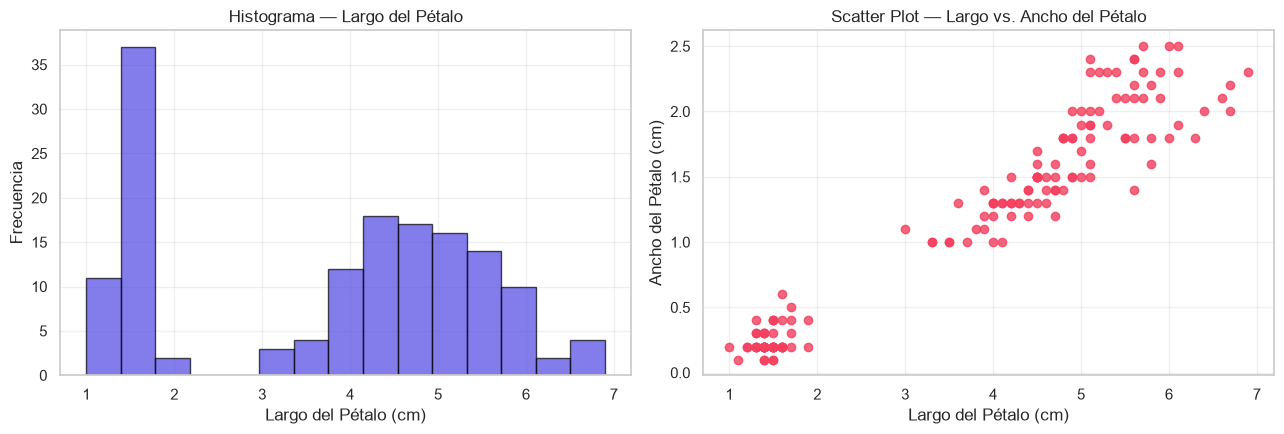

Coeficiente de correlación de Pearson (r): 0.9629


In [6]:
largo_petalo = df_iris_base["petal length (cm)"].to_numpy()
ancho_petalo = df_iris_base["petal width (cm)"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Histograma del largo del pétalo
axes[0].hist(largo_petalo, bins=15, color=INDIGO, edgecolor="black", alpha=0.7)
axes[0].set_title("Histograma — Largo del Pétalo")
axes[0].set_xlabel("Largo del Pétalo (cm)")
axes[0].set_ylabel("Frecuencia")

# 2. Diagrama de Dispersión (Scatter Plot)
axes[1].scatter(largo_petalo, ancho_petalo, color=CORAL, alpha=0.8)
axes[1].set_title("Scatter Plot — Largo vs. Ancho del Pétalo")
axes[1].set_xlabel("Largo del Pétalo (cm)")
axes[1].set_ylabel("Ancho del Pétalo (cm)")

plt.tight_layout()
plt.show()

# 3. Coeficiente de correlación de Pearson
corr_matrix = np.corrcoef(largo_petalo, ancho_petalo)
r = corr_matrix[0, 1]
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")

### RESPUESTAS:

* **Coeficiente de correlación obtenido:** $r = 0.9629$[cite: 3].
* **¿Coincide el número con la nube de puntos?**
  **Sí, coincide perfectamente.** El gráfico de dispersión muestra una clara tendencia ascendente donde a mayores valores de largo de pétalo corresponden mayores valores de ancho[cite: 3].
* **Interpretación de signo y magnitud:**
  * **Signo (+):** Indica una relación directa o positiva; ambas variables crecen simultáneamente[cite: 3].
  * **Magnitud ($0.9629 \approx +1$):** Al estar extremadamente cercano a $+1$, señala una **correlación lineal directa casi perfecta**[cite: 3].
  * *Significados teóricos:* Un valor cercano a $+1$ indica relación lineal positiva perfecta; un valor cercano a $0$ indica ausencia de relación lineal; y un valor cercano a $-1$ indica relación lineal inversa perfecta[cite: 3].

## EJERCICIO 06: Perfil estadístico por especie

Comparamos las tres especies de Iris agrupadamente calculando media, mediana, desviación estándar, rango y cuartiles ($Q_1, Q_2, Q_3$)[cite: 3].

In [7]:
# Carga de Iris en DataFrame con especies
df_iris_full = pd.DataFrame(X_iris, columns=iris_data.feature_names)
df_iris_full['species'] = [iris_data.target_names[i] for i in y_iris]

# Función para calcular rango
def rango(s):
    return s.max() - s.min()

# Agrupación y cálculo de estadísticos
perfil_especie = df_iris_full.groupby('species').agg([
    'mean', 
    'median', 
    'std', 
    rango, 
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75)
])

# Renombrar columnas para claridad
perfil_especie.columns = pd.MultiIndex.from_tuples([
    (col, stat) for col, stat in zip(
        perfil_especie.columns.get_level_values(0),
        ['Media', 'Mediana', 'Std', 'Rango', 'Q1', 'Q3'] * 4
    )
])

perfil_especie.T

species                      setosa  versicolor  virginica
sepal length (cm) Media    5.006000    5.936000   6.588000
                  Mediana  5.000000    5.900000   6.500000
                  Std      0.352490    0.516171   0.635880
                  Rango    1.500000    2.100000   3.000000
                  Q1       4.800000    5.600000   6.225000
                  Q3       5.200000    6.300000   6.900000
sepal width (cm)  Media    3.428000    2.770000   2.974000
                  Mediana  3.400000    2.800000   3.000000
                  Std      0.379064    0.313798   0.322497
                  Rango    2.100000    1.400000   1.600000
                  Q1       3.200000    2.525000   2.800000
                  Q3       3.675000    3.000000   3.175000
petal length (cm) Media    1.462000    4.260000   5.552000
                  Mediana  1.500000    4.350000   5.550000
                  Std      0.173664    0.469911   0.551895
                  Rango    0.900000    2.100000   2.400000
                  Q1       1.400000    4.000000   5.100000
                  Q3       1.575000    4.600000   5.875000
petal width (cm)  Media    0.246000    1.326000   2.026000
                  Mediana  0.200000    1.300000   2.000000
                  Std      0.105386    0.197753   0.274650
                  Rango    0.500000    0.800000   1.100000
                  Q1       0.200000    1.200000   1.800000
                  Q3       0.300000    1.500000   2.300000

### RESPUESTAS:

* **¿Qué característica separa mejor a las tres especies y por qué?**
  La característica que separa mejor a las tres especies es **`petal length (cm)` (largo del pétalo)**[cite: 3].
* **Argumentación técnica:**
  * **Medias muy distintas entre especies:** *Setosa* presenta una media de $1.46\text{ cm}$, *Versicolor* de $4.26\text{ cm}$ y *Virginica* de $5.55\text{ cm}$[cite: 3].
  * **Baja dispersión interna:** La desviación estándar dentro de cada especie para esta variable es pequeña ($0.17$, $0.47$ y $0.55$ respectivamente)[cite: 3].
  * Esta combinación de medias distantes con baja dispersión intraclase evita que los rangos numéricos de las especies se solapen, produciendo un límite de separación casi perfecto[cite: 3].

## EJERCICIO 07: Tres formas de comparar dos flores, hechas por ti

Implementamos desde cero tres métricas de similitud/distancia vectorial con NumPy puro y las aplicamos sobre pares de flores de la misma especie y de especies distintas[cite: 3].

In [8]:
# 1. Definición de funciones vectoriales a mano
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def producto_punto(a, b):
    return np.sum(a * b)

def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 2. Selección de 4 flores:
# f0 (Setosa), f1 (Setosa) -> Misma especie
# f50 (Versicolor), f100 (Virginica) -> Especies distintas
f0 = X_iris[0]
f1 = X_iris[1]
f50 = X_iris[50]
f100 = X_iris[100]

pares = {
    "Setosa (0) vs Setosa (1) [Misma]": (f0, f1),
    "Setosa (0) vs Versicolor (50) [Distinta]": (f0, f50),
    "Versicolor (50) vs Virginica (100) [Distinta]": (f50, f100)
}

res_e7 = []
for nombre, (a, b) in pares.items():
    res_e7.append({
        "Par de flores": nombre,
        "Distancia Euclidiana": distancia_euclidiana(a, b),
        "Producto Punto": producto_punto(a, b),
        "Similitud Coseno": similitud_coseno(a, b)
    })

pd.DataFrame(res_e7)

,Par de flores,Distancia Euclidiana,Producto Punto,Similitud Coseno
0,Setosa (0) vs Setosa (1) [Misma],0.538516,37.49,0.998579
1,Setosa (0) vs Versicolor (50) [Distinta],4.003748,53.76,0.928380
2,Versicolor (50) vs Virginica (100) [Distinta],1.843909,86.36,0.982137


### RESPUESTAS:

* **¿La similitud coseno y la distancia euclidiana ordenan las flores igual?**
  **No necesariamente ordenan exactamente igual en todos los casos.** 
  * La **distancia euclidiana** mide la separación física o magnitud de la diferencia vectorial (menor valor implica mayor similitud)[cite: 3].
  * La **similitud coseno** mide el ángulo entre los vectores sin importar su magnitud o escala (un valor más cercano a $1$ implica mayor similitud angular)[cite: 3].
* **¿En qué caso discrepan y por qué ocurre?**
  Discrepan cuando dos flores tienen una forma idéntica proporcionalmente (mismo ángulo vectorial) pero magnitudes absolutas muy diferentes (una flor es el doble de grande que la otra)[cite: 3]. La similitud coseno indicará que son casi idénticas ($\cos \theta \approx 1$), mientras que la distancia euclidiana dirá que están lejanas debido a la diferencia en sus longitudes vectoriales[cite: 3].

## EJERCICIO 08: Leer los datos con la vista

Generamos tres visualizaciones clave (Pairplot, Heatmap de correlaciones y Boxplots) para interpretar la separabilidad lineal de las especies[cite: 3].

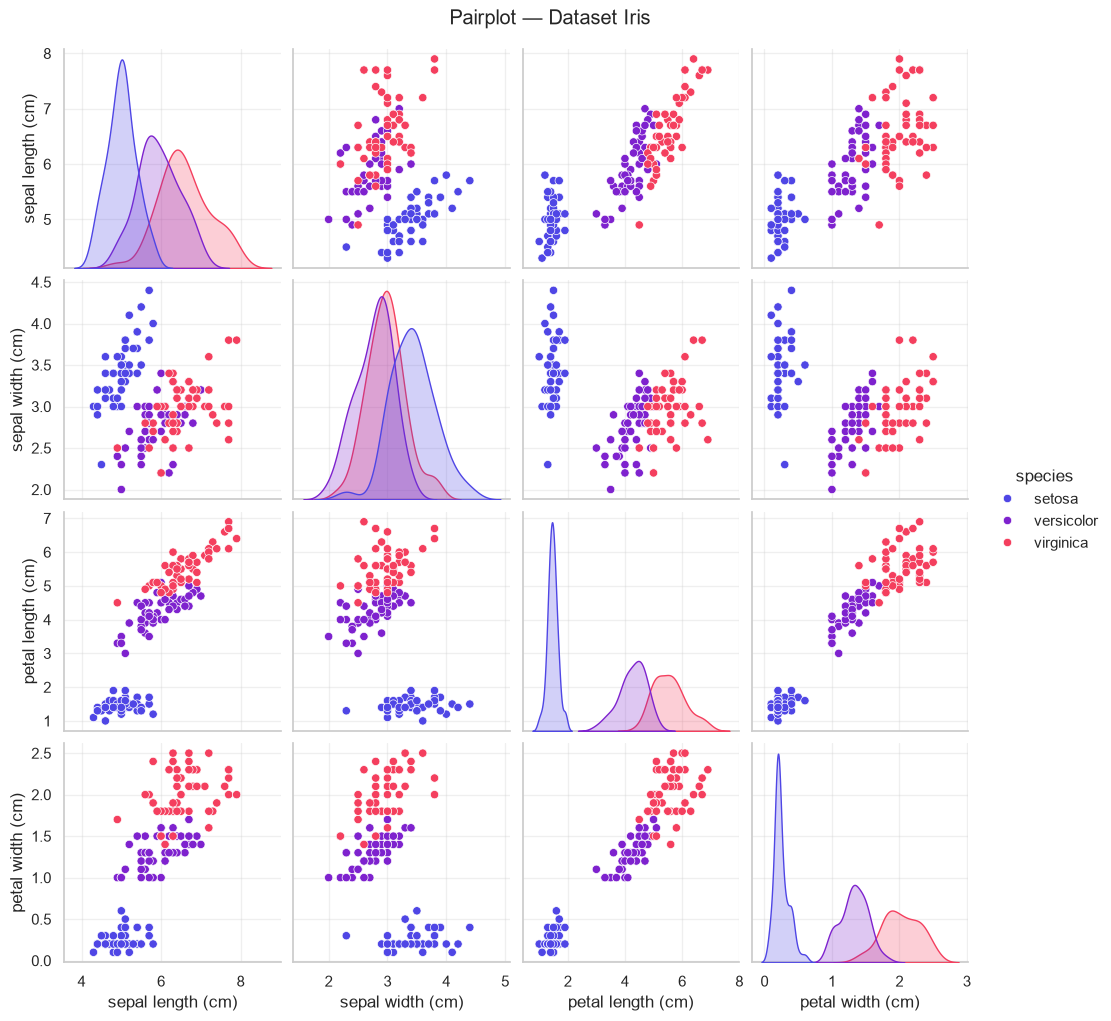

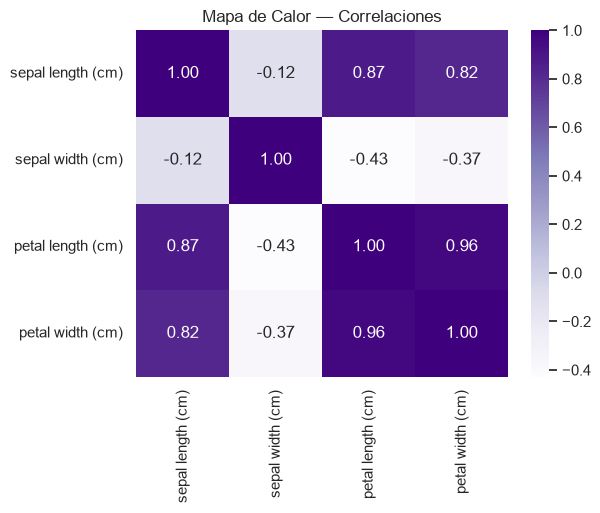

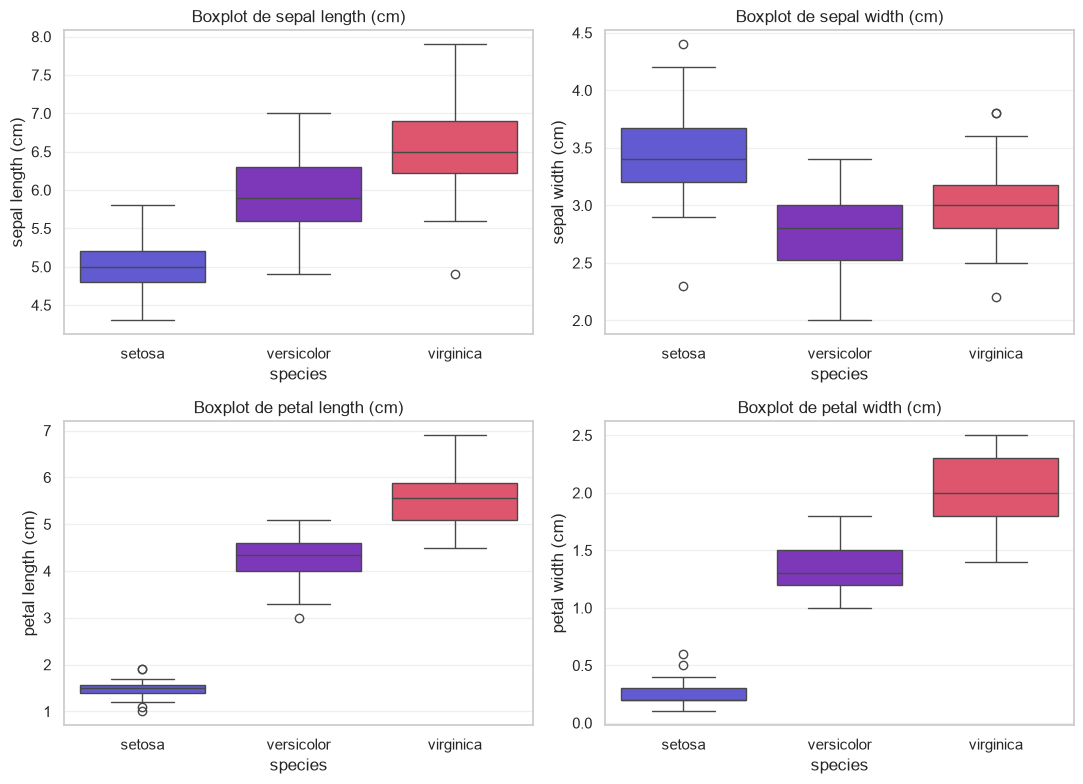

In [10]:
# 1. Pairplot
sns.pairplot(df_iris_full, hue='species', palette=[INDIGO, PURPURA, CORAL])
plt.suptitle("Pairplot — Dataset Iris", y=1.02)
plt.show()

# 2. Heatmap de correlación
plt.figure(figsize=(6, 4.5))
sns.heatmap(df_iris_full.drop(columns=['species']).corr(), annot=True, cmap="Purples", fmt=".2f")
plt.title("Mapa de Calor — Correlaciones")
plt.show()

# 3. Boxplots por característica (Corregido para evitar FutureWarning)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
cols = iris_data.feature_names

for ax, col in zip(axes.ravel(), cols):
    sns.boxplot(
        data=df_iris_full, 
        x='species', 
        y=col, 
        hue='species', 
        palette=[INDIGO, PURPURA, CORAL], 
        ax=ax, 
        legend=False
    )
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### RESPUESTAS:

* **Lectura del análisis gráfico:**
  * **Par que separa bien (Separación lineal clara):** El par formado por **`petal length` vs. `petal width`**[cite: 3]. En el *pairplot*, la especie *Setosa* aparece completamente aislada en un cluster separado, mientras que *Versicolor* y *Virginica* son divisibles trazando un límite rectilíneo muy claro[cite: 3].
  * **Par que se solapa (Confunde especies):** El par **`sepal length` vs. `sepal width`**[cite: 3]. En el diagrama de dispersión, los puntos de las tres especies se superponen fuertemente, haciendo imposible separar las especies trazando una sola línea recta entre ellas[cite: 3].

## EJERCICIO 09: Bajar la colina: descenso de gradiente a mano

Optimizamos la función cuadrática $f(x) = (x - 3)^2 + 2$ buscando su mínimo en $x = 3$ mediante estimación numérica de la derivada por diferencias finitas[cite: 3].

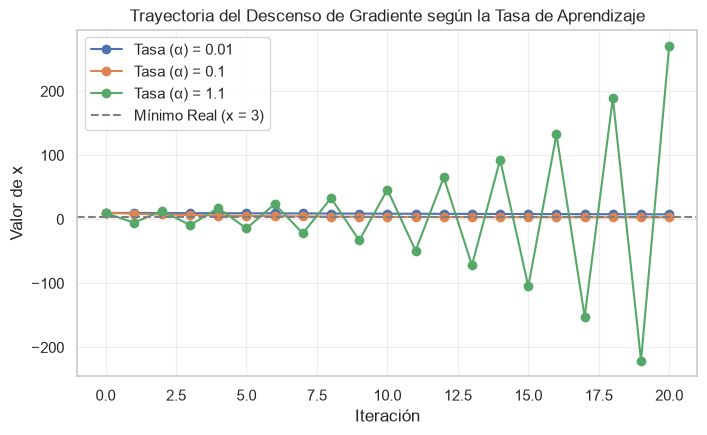

In [11]:
# 1. Definición de la función y su derivada numérica por diferencias finitas
def f(x):
    return (x - 3)**2 + 2

def derivada(x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

# 2. Algoritmo de Descenso de Gradiente
def descenso_gradiente(x_inicial, tasa, pasos=30):
    x = x_inicial
    historia = [x]
    for _ in range(pasos):
        grad = derivada(x)
        x = x - tasa * grad
        historia.append(x)
    return historia

# 3. Experimentación con tres tasas de aprendizaje
tasas = [0.01, 0.1, 1.1]
x_0 = 10.0
pasos = 20

plt.figure(figsize=(8, 4.5))
for alpha in tasas:
    trayectoria = descenso_gradiente(x_0, alpha, pasos)
    plt.plot(range(pasos + 1), trayectoria, "o-", label=f"Tasa (α) = {alpha}")

plt.axhline(3.0, color="gray", linestyle="--", label="Mínimo Real (x = 3)")
plt.xlabel("Iteración")
plt.ylabel("Valor de x")
plt.title("Trayectoria del Descenso de Gradiente según la Tasa de Aprendizaje")
plt.legend()
plt.show()

### RESPUESTAS 

* **Comportamiento según la tasa de aprendizaje ($\alpha$):**
  * **Tasa pequeña ($\alpha = 0.01$):** Avanza de forma excesivamente lenta hacia el mínimo; requiere muchas iteraciones para converger a $x = 3$[cite: 3].
  * **Tasa intermedia ($\alpha = 0.1$):** Converge de manera suave, eficiente y directa hacia $x = 3$ en pocas iteraciones[cite: 3].
  * **Tasa grande ($\alpha = 1.1$):** Se pasa del mínimo, provocando oscilaciones divergentes que se alejan cada vez más del valor real[cite: 3].
* **¿Por qué la elección de la tasa es delicada?**
  Porque una tasa demasiado pequeña hace que el entrenamiento del modelo sea extremadamente lento e ineficiente, mientras que una tasa excesivamente grande provoca inestabilidad numérica u oscilaciones que impiden que el algoritmo alcance el mínimo de la función de pérdida[cite: 3].

## EJERCICIO 10: Contar y simular: dos caminos hacia una probabilidad

Calculamos la probabilidad del evento **"al menos un 6 al tirar cuatro dados"**[cite: 3] mediante enumeración exacta del espacio muestral ($6^4 = 1,296$ casos) y mediante simulación frecuentista analizando su convergencia[cite: 3].

Total casos posibles: 1296
Casos favorables (al menos un 6): 671
Probabilidad exacta (teórica): 0.51775


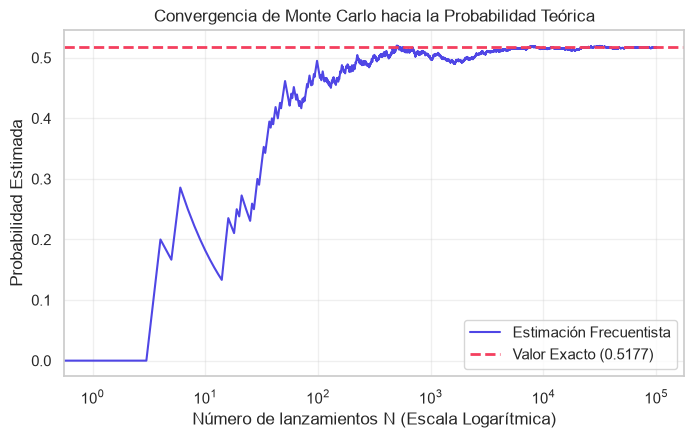

,N (Muestras),Prob. Estimada,Valor Exacto,Error Absoluto
0,10,0.20000,0.517747,0.317747
1,100,0.49000,0.517747,0.027747
2,10000,0.51620,0.517747,0.001547
3,100000,0.51654,0.517747,0.001207


In [12]:
# 1. Conteo Exacto (Valor Teórico)
# Espacio muestral para n=4 dados (6^4 = 1296 casos posibles)
espacio_muestral = list(itertools.product(range(1, 7), repeat=4))
casos_favorables = sum(1 for tirada in espacio_muestral if 6 in tirada)
prob_exacta = casos_favorables / len(espacio_muestral)

print(f"Total casos posibles: {len(espacio_muestral)}")
print(f"Casos favorables (al menos un 6): {casos_favorables}")
print(f"Probabilidad exacta (teórica): {prob_exacta:.5f}")

# 2 y 3. Simulación y Convergencia
tamanos_N = [10, 100, 10000, 100000]
errores = []
estimaciones = []

# Simulación masiva previa para gráfico continuo
tiradas_sim = rng.integers(1, 7, size=(100000, 4))
es_seis = (tiradas_sim == 6).any(axis=1)

for N in tamanos_N:
    est = es_seis[:N].mean()
    estimaciones.append(est)
    errores.append(abs(est - prob_exacta))

# Gráfico de convergencia
cum_estimates = np.cumsum(es_seis) / np.arange(1, 100001)

plt.figure(figsize=(8, 4.5))
plt.plot(cum_estimates, color=INDIGO, label="Estimación Frecuentista")
plt.axhline(prob_exacta, color=CORAL, linestyle="--", linewidth=2, label=f"Valor Exacto ({prob_exacta:.4f})")
plt.xscale('log')
plt.xlabel("Número de lanzamientos N (Escala Logarítmica)")
plt.ylabel("Probabilidad Estimada")
plt.title("Convergencia de Monte Carlo hacia la Probabilidad Teórica")
plt.legend()
plt.show()

# Tabla de error por tamaño de muestra
pd.DataFrame({
    "N (Muestras)": tamanos_N,
    "Prob. Estimada": estimaciones,
    "Valor Exacto": prob_exacta,
    "Error Absoluto": errores
})

### RESPUESTAS:

* **Valor exacto por conteo:** $P(\text{al menos un 6 en 4 dados}) = \frac{671}{1296} \approx \mathbf{0.51775}$[cite: 3].
* **¿A partir de qué $N$ la estimación se vuelve confiable?**
  La estimación se vuelve confiable a partir de **$N = 10\,000$**, donde el error absoluto cae por debajo de $0.005$ y la curva se estabiliza alrededor de la línea del valor exacto teórico[cite: 3].
* **¿Qué relación notas entre el número de tiradas y el error?**
  Existe una **relación inversamente proporcional**: a medida que el número de tiradas ($N$) aumenta, el error de estimación disminuye progresivamente siguiendo la tasa de convergencia estocástica $\mathcal{O}(1/\sqrt{N})$[cite: 3].